# Phần 3: Linear Regression (Hồi quy tuyến tính)

## A. Đọc hiểu (Lý thuyết cơ bản)

### Mục đích
Thuật toán này giải quyết các bài toán có đầu ra là giá trị thực (continuous values), ví dụ như dự đoán giá nhà dựa trên diện tích mét vuông.

### Mô hình (Model)
Bài toán đi tìm một đường thẳng gần nhất với các điểm dữ liệu. Phương trình tổng quát có dạng:  
$\hat{y}_i = w_1 \cdot x_i + w_0$,  
trong đó $x_i$ là đầu vào (diện tích), $\hat{y}_i$ là giá trị dự đoán, $w_1$ là trọng số (weight) và $w_0$ là hệ số tự do (bias).

### Hàm mất mát (Loss function)
Để đánh giá đường thẳng có khớp với dữ liệu hay không, ta đo sự chênh lệch giữa giá thực tế ($y_i$) và giá dự đoán ($\hat{y}_i$). Linear regression thường dùng hàm trung bình bình phương sai số (Mean Squared Error - MSE):  
$J = \frac{1}{2N} \sum (\hat{y}_i - y_i)^2$.  
Giá trị J càng nhỏ thì đường thẳng càng gần điểm dữ liệu.

### Tối ưu hóa bằng Gradient Descent
Để tìm được $w_0, w_1$ sao cho J nhỏ nhất, máy tính khởi tạo giá trị ngẫu nhiên, sau đó sử dụng thuật toán Gradient Descent để cập nhật tham số ngược hướng với đạo hàm:  
$w = w - learning\_rate \cdot \frac{\partial J}{\partial w}$.  
Quá trình này lặp lại nhiều lần cho đến khi sai số đủ nhỏ.

## B. Implement (Code Python bằng Numpy)
Tài liệu hướng dẫn lập trình thuật toán này từ con số 0 bằng ma trận và thư viện Numpy.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Đọc dữ liệu
# Giả sử file 'data_linear.csv' có 2 cột: diện tích (x) và giá nhà (y)
# Nếu không có file, tạo dữ liệu mẫu
try:
    data = pd.read_csv('data_linear.csv').values
except FileNotFoundError:
    # Tạo dữ liệu mẫu nếu file không tồn tại
    np.random.seed(42)
    x_vals = np.random.uniform(20, 100, 100)  # Diện tích từ 20-100 m²
    y_vals = 2 * x_vals + 10 + np.random.normal(0, 5, 100)  # Giá = 2*x + 10 + noise
    data = np.column_stack((x_vals, y_vals))

N = data.shape[0]
x = data[:, 0].reshape(-1, 1)  # Diện tích
y = data[:, 1].reshape(-1, 1)  # Giá nhà

In [3]:
# 2. Thêm cột 1 vào x để tính hệ số bias w0
x = np.hstack((np.ones((N, 1)), x))

In [4]:
# 3. Khởi tạo tham số w0, w1 ngẫu nhiên
w = np.array([0., 1.]).reshape(-1, 1)

In [5]:
# 4. Thiết lập tham số cho Gradient Descent
numOfIteration = 100
cost = np.zeros((numOfIteration, 1))
learning_rate = 0.000001

In [6]:
# 5. Huấn luyện mô hình (Training)
for i in range(1, numOfIteration):
    # Tính giá trị dự đoán và sai số r
    r = np.dot(x, w) - y
    
    # Tính Loss function
    cost[i] = 0.5 * np.sum(r * r)
    
    # Cập nhật trọng số w0 và w1 bằng Gradient Descent
    w[0] -= learning_rate * np.sum(r)  # Cập nhật w0 (bias)
    w[1] -= learning_rate * np.sum(np.multiply(r, x[:, 1].reshape(-1, 1)))  # Cập nhật w1

In [7]:
# 6. Dự đoán dữ liệu mới (Ví dụ: nhà 50m²)
x1 = 50
y1 = w[0] + w[1] * x1
print('Giá nhà cho 50m² là : ', y1[0])

Giá nhà cho 50m² là :  107.22156802378142


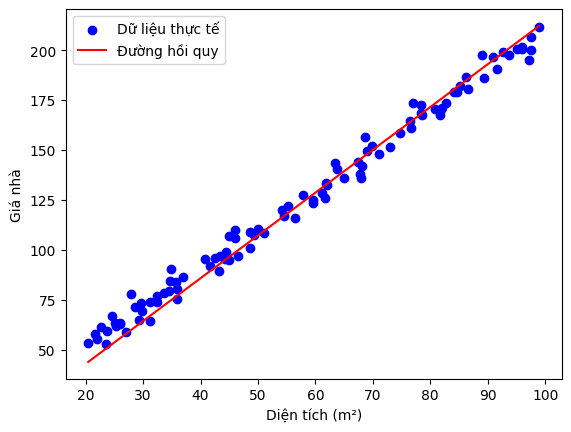

In [8]:
# Vẽ biểu đồ dữ liệu và đường hồi quy
plt.scatter(data[:, 0], data[:, 1], color='blue', label='Dữ liệu thực tế')
x_plot = np.linspace(data[:, 0].min(), data[:, 0].max(), 100)
y_plot = w[0] + w[1] * x_plot
plt.plot(x_plot, y_plot, color='red', label='Đường hồi quy')
plt.xlabel('Diện tích (m²)')
plt.ylabel('Giá nhà')
plt.legend()
plt.show()

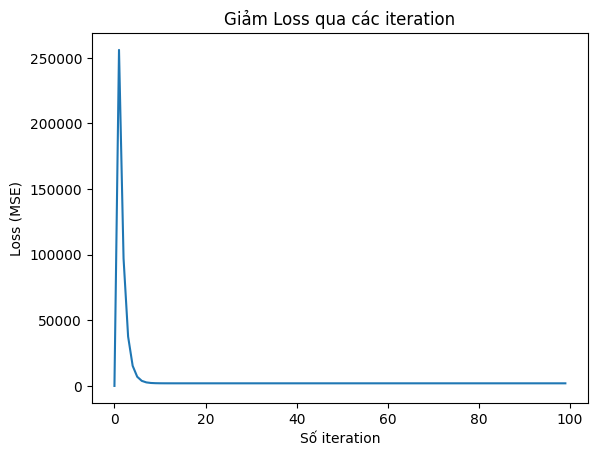

In [9]:
# Vẽ biểu đồ Loss function theo số iteration
plt.plot(range(numOfIteration), cost)
plt.xlabel('Số iteration')
plt.ylabel('Loss (MSE)')
plt.title('Giảm Loss qua các iteration')
plt.show()

### Ghi chú: Cách implement ngắn gọn hơn bằng thư viện sklearn.linear_model.LinearRegression

In [10]:
from sklearn.linear_model import LinearRegression

# Sử dụng sklearn
model = LinearRegression()
model.fit(data[:, 0].reshape(-1, 1), data[:, 1])  # x là diện tích, y là giá

# Dự đoán
y_pred_sklearn = model.predict([[50]])
print('Giá nhà cho 50m² (sklearn): ', y_pred_sklearn[0])
print('w0 (intercept): ', model.intercept_)
print('w1 (slope): ', model.coef_[0])

Giá nhà cho 50m² (sklearn):  110.21340598687806
w0 (intercept):  11.650197321637549
w1 (slope):  1.9712641733048102
